# Predicción de ventas usando regresión lineal múltiple 


In [32]:
# 1. Preparación de los datos
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Importamos nuestros datos
df = pd.read_csv('car_prices.csv')

# Mostramos los primeros 5 registros para conocer nuestros datos
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


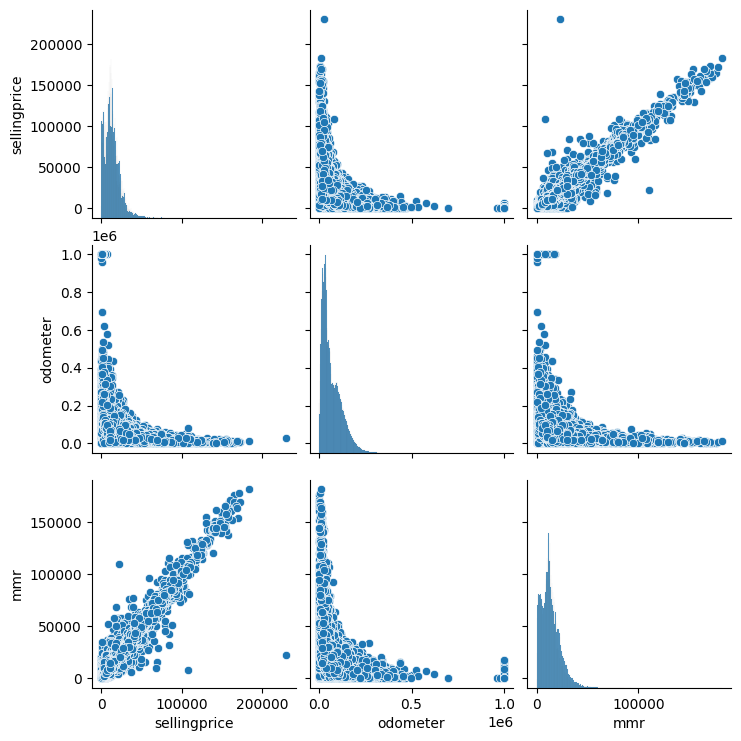

In [33]:
# 2. Análisis exploratorio

# Seleccionamos las columnas que vamos a utilizar
columnas_relevantes = ['sellingprice', 'odometer', 'mmr']
df_subset = df[columnas_relevantes].dropna() 

# Creamos el pairplot
sns.pairplot(df_subset)
plt.show()



In [34]:
# 3. Identificación de variables

df_limpio = df.dropna(subset=['odometer', 'mmr', 'sellingprice'])

# Definimos las variables independientes y la dependiente
X = df_limpio[['odometer', 'mmr']].values
y = df_limpio['sellingprice'].values

# 4. División de datos

# Dividimos los datos 80/20 (80% para entrenar y 20% para la prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {len(X_train)} registros")
print(f"Datos de prueba: {len(X_test)} registros")


Datos de entrenamiento: 446964 registros
Datos de prueba: 111741 registros


In [35]:
# 5. Modelado

# Creamos la instancia de nuestro modelo
modelo = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento 
modelo.fit(X_train, y_train)

print("Modelo entrenado exitosamente")

# 6. Evaluación del modelo

# Calculamos el puntaje de R cuadrado
score = modelo.score(X_test, y_test)

print(f"El coeficiente de determinación es: {score: .4f}")

Modelo entrenado exitosamente
El coeficiente de determinación es:  0.9686


In [36]:
# 7. Predicción
y_pred = modelo.predict(X_test)

# Mostramos nuestra predicciones y comparamos con los valores reales
print("Primeros 5 predicciones")
print(y_pred[:5])
print("Valores reales correspondientes")
print(y_test[:5])


Primeros 5 predicciones
[12343.08655889 18680.20224707 12623.26390807  5859.95782909
 17151.71649625]
Valores reales correspondientes
[11200. 16900. 13600.  4800. 17400.]


In [38]:
# 8. Error cuadrático medio
 
# Calculamos el MSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Error Cuadrático Medio (MSE): {mse:.2f} ")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f} ")

Error Cuadrático Medio (MSE): 2995581.36 
Raíz del Error Cuadrático Medio (RMSE): 1730.77 


### Conclusión
**Eficacia del modelo:** El modelo de regresión lineal múltiple resultó ser altamente eficaz, logrando explicar el 96.86% de la variabilidad en los precios de venta. Esto confirma que el kilometraje y la valoración de mercado son factores determinantes para fijar el precio de un vehículo.

**Precisión:** El error promedio de `1730.77` es relativamente bajo en comparación con el valor total de los vehículos, lo cual nos indica que las predicciones son útiles para una estimación rápida de precios en el mercado

**Posibles mejoras:**
* Limpieza de datos
* Incluir nuevas variables
    * Estado del vehículo (ya que factores estéticos también llegan a influir)